# Create bathymetry function
You can execute all the cells and get the piece-wise polynomial in the last cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as si 

### Read csv file

Maximal water height (scaled): 2.7952999999999997 = 4.19295 km


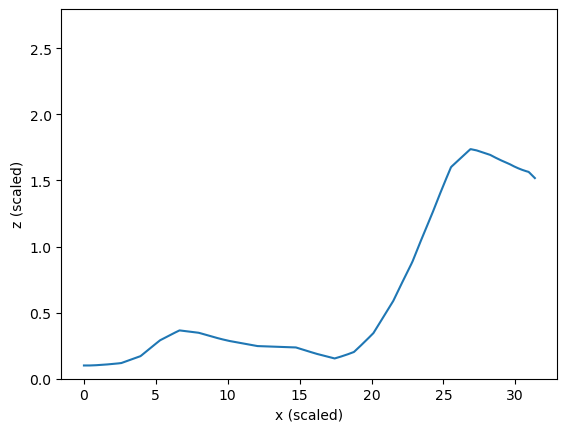

In [101]:
import csv
z = []
x = []
with open('../../../../data_bathy/data2.csv', newline='') as csvfile:
    spamreader = csv.reader(csvfile, delimiter=',', quotechar='|')
    for line in spamreader:
        # print(line)
        # z.append(line[0]) for data.csv
        # x.append(line[2]) # for data.csv
        x.append(line[0]) # for data2.csv
        z.append(line[1]) # for data2.csv

z = np.astype(np.array(z[1:]), float)
x = np.astype(np.array(x[1:]), float)

# For the function, scale the data and offset such that ocean seabed is at z=0 (we might want to change this in the future)
x_adim = x/1500
z_adim = (z-np.min(z))/1500 + 0.1
h_adim = -np.min(z)/1500 
xmax_adim = np.max(x_adim)
print("Maximal water height (scaled):", h_adim, "=", h_adim * 1.5, "km")
plt.plot(x_adim,z_adim)
plt.xlabel("x (scaled)")
plt.ylabel("z (scaled)")
plt.ylim(0,h_adim)
plt.show()

### Interpolate as a piece-wise linear function

Data size:  1001
Nb of breakpoints for the piecewise linear interpolation: 14


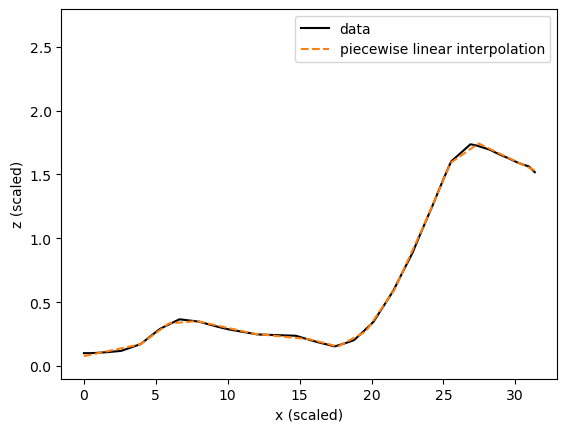

In [ ]:
plt.plot(x_adim,z_adim, color="k", label="data")
print("Data size: ", x_adim.size)

# Create spline with approximated knots to reduce the number of breakpoints needed
spl = si.make_splrep(x_adim, z_adim, k=1, s=0.1)
x_test = np.linspace(0,xmax_adim,x.size)

# Convert to piecezise
poly = si.PPoly.from_spline(spl)
print("Nb of breakpoints for the piecewise linear interpolation:", poly.c.shape[1])
#print(poly.c[0,:])
#print(poly.c[1,:])
plt.plot(x_test, poly(x_test), "--", color="C1", label='piecewise linear interpolation')

plt.xlabel("x (scaled)")
plt.ylabel("z (scaled)")
plt.ylim(-0.1,h_adim)
plt.legend()
plt.show()

PPoly: Piecewise polynomial in python.
The polynomial between $x_i$ and $x_{i+1}$ is written 
$$
P(x) = \sum_{m=0}^k c_{m,i} \cdot (x - x_i)^{k-m}.
$$
In our case, $k=1$. For $m+1$ polynomial breakpoints $x_0, \dots, x_m$ and $m$ coefficients $c_{0,0}, \dots c_{0,m-1}$ and  $c_{1,0}, \dots c_{1,m-1}$, we have 
$$
P(x) = \sum_{i=0}^{m-1} \left(c_{0,i} \cdot (x - x_i) +  c_{1,i} \right) \bm{1}_{[x_i, x_i+1]}
$$

In [109]:
print("Polynomial breakpoints x_0, ... x_m: \n", poly.x)
print("\n Linear part: Polynomial coefficients  c_{0,0} ... c_{0,m-1}: \n", poly.c[0,:])
print("\n Constant part: Polynomial coefficients  c_{1,0} ... c_{1,m-1}: \n", poly.c[1,:])


Polynomial breakpoints x_0, ... x_m: 
 [ 0.          0.          3.92014667  5.89587333  7.8402     11.76033333
 15.68053333 17.6562     19.60066667 21.5764     23.5208     25.49653333
 27.44086667 31.361      31.361     ]

 Linear part: Polynomial coefficients  c_{0,0} ... c_{0,m-1}: 
 [ 0.02340215  0.02340215  0.08316898  0.0097372  -0.02517783 -0.01112273
 -0.02963418  0.06059417  0.16377212  0.24500158  0.26413911  0.07844746
 -0.0540527  -0.0540527 ]

 Constant part: Polynomial coefficients  c_{1,0} ... c_{1,m-1}: 
 [0.07699158 0.07699158 0.16873143 0.33305059 0.3519829  0.25328244
 0.2096791  0.15113183 0.26895517 0.59252521 1.06890628 1.59077472
 1.74330274 1.53140894]


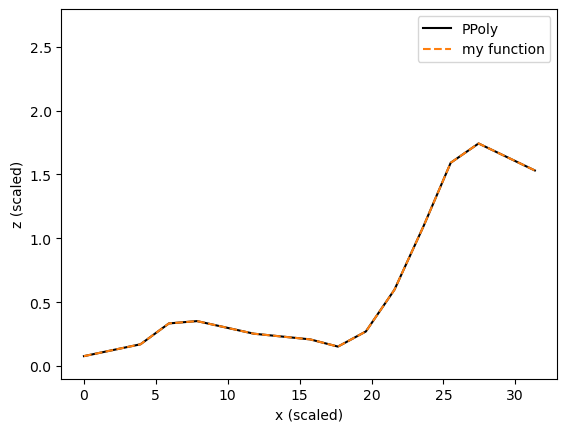

In [ ]:
# In case there is no PPoly class in julia: here is how we can define the function based on the coefficients arrays

from bisect import bisect_right
def f(x):
    assert x>=0
    idx = bisect_right(poly.x, x) - 1
    if(idx < poly.x.size - 1 ):
        slope, offset = poly.c[:,idx]
        breakpoint = poly.x[idx]
        return offset + (x-breakpoint)*slope
    else: # after last breakpoint: 
        return poly.c[1,-1]


#### Plot to check
f_test = []
for x_ in x_test:
    f_test.append(f(x_))


plt.plot(x_test, poly(x_test), color="k", label='PPoly')
plt.plot(x_test, f_test, "--", color="C1", label='my function')

plt.xlabel("x (scaled)")
plt.ylabel("z (scaled)")
plt.ylim(-0.1,h_adim)
plt.legend()
plt.show()